In [1]:
import numpy as np
from sklearn.datasets import load_diabetes

*directly returns numpy arrays*

In [2]:
X,y = load_diabetes(return_X_y=True)

In [3]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [4]:
X.shape

(442, 10)

input columns are 10, and no of rows are 442

In [5]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [6]:
y.shape

(442,)

# **Using Sklearn's Linear Regression**

In [7]:
from sklearn.model_selection import train_test_split


In [8]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=2
)

In [9]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


353 rows in train, 89 rows in test

In [10]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

weightage -> beta 1 to beta 10

In [11]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

offset -> beta 0 , when there is value 0 for inputs , let us say experience of a fresher is 0, so salary is 0 ? nope.
that is why we add offset

In [12]:
reg.intercept_

np.float64(151.88331005254167)

In [15]:
y_pred = reg.predict(X_test)

In [13]:
from sklearn.metrics import r2_score

In [16]:
r2_score(y_test,y_pred)

0.4399338661568968

# **Making my own Linear Regression Class**

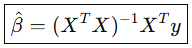

since $$ (X^T X)^{-1} $$
is a square matrix of shape (m+1,m+1).
Let us say we have 999 columns, so the shape becomes (1000,1000), so n becomes 1000 , and using the Gauss Jordian elimination technique we have
TC -> O(n^3) = 10^9 computations which will make the model very slow when working with large datasets, that is why we use gradient descent, which is inside the SGDRegressor class of sklearn.
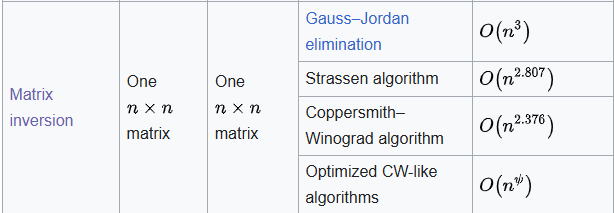

In [23]:
class MyMultipleLR:

  def __init__(self):
    # initialise the coeff and intercept values
    self.coef_ = None
    self.intercept_ = None

  # for training the model to
  # find the coeff and intercept values
  def fit(self,X_train,y_train):
    # transform the X_train
    X_train = np.insert(X_train,0,1,axis=1)
    # calculate the coef matrix
    betas = np.linalg.inv(
      np.dot(X_train.T,X_train)
    ).dot(X_train.T).dot(y_train)
    # we will get beta 0,....beta m
    # where m is the number of input columns
    self.intercept_ = betas[0]
    self.coef_ = betas[1:]

  # for prediction
  def predict(self,X_test):
    y_pred = np.dot(X_test,self.coef_) + self.intercept_
    return y_pred


In [24]:
lr = MyMultipleLR()
lr.fit(X_train,y_train)

In [25]:
X_train.shape

(353, 10)

*we need to add a column full of 1's in our X_train at index 0 as per the mathematical formulation*

In [20]:
np.insert(
    X_train,0,1,axis=1
)

array([[ 1.        , -0.00188202, -0.04464164, ..., -0.03949338,
        -0.06291688,  0.04034337],
       [ 1.        , -0.00914709, -0.04464164, ..., -0.03949338,
         0.01703607, -0.0052198 ],
       [ 1.        ,  0.02354575,  0.05068012, ..., -0.03949338,
        -0.09643495, -0.01764613],
       ...,
       [ 1.        ,  0.06350368,  0.05068012, ..., -0.00259226,
         0.08449153, -0.01764613],
       [ 1.        , -0.05273755,  0.05068012, ...,  0.1081111 ,
         0.03606033, -0.04249877],
       [ 1.        ,  0.00175052,  0.05068012, ...,  0.1081111 ,
         0.06898589,  0.12732762]])

In [21]:
np.insert(
    X_train,0,1,axis=1
).shape

(353, 11)

In [26]:
y_pred = lr.predict(X_test)

In [27]:
r2_score(y_test,y_pred)

0.43993386615689634

In [28]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [29]:
lr.intercept_

np.float64(151.88331005254165)